In [1]:
import torch as th
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import dgl
from dgl.data import TUDataset
import os
import time
from torch.utils.data import DataLoader, TensorDataset, random_split

# Import the original classes from your local model.py file
from model import Ring_GNN, MLP, equi_2_to_2

# Parrot Fixed Boundary
N_MAX = 28 
INPUT_DIM = N_MAX * N_MAX  # 784
OUTPUT_BASIS = 15          
OUTPUT_DIM = OUTPUT_BASIS * N_MAX * N_MAX # 11,760

print(f"Parrot configuration: Input={INPUT_DIM}, Output={OUTPUT_DIM}")

Parrot configuration: Input=784, Output=11760


In [2]:
def ops_2_to_2(inputs, dim, normalization='inf'): 
    # inputs: N x D x m x m
    diag_part = th.diagonal(inputs, dim1=2, dim2=3) 
    sum_diag_part = th.sum(diag_part, dim=2, keepdim=True) 
    sum_of_rows = th.sum(inputs, dim=3) 
    sum_of_cols = th.sum(inputs, dim=2) 
    sum_all = th.sum(sum_of_rows, dim=2) 

    # Generate the 15 operators (Basis)
    op1 = th.diag_embed(diag_part)
    op2 = th.diag_embed(sum_diag_part.repeat(1, 1, dim))
    op3 = th.diag_embed(sum_of_rows)
    op4 = th.diag_embed(sum_of_cols)
    op5 = th.diag_embed(sum_all.unsqueeze(2).repeat(1, 1, dim))
    op6 = sum_of_cols.unsqueeze(3).repeat(1, 1, 1, dim)
    op7 = sum_of_rows.unsqueeze(3).repeat(1, 1, 1, dim)
    op8 = sum_of_cols.unsqueeze(2).repeat(1, 1, dim, 1)
    op9 = sum_of_rows.unsqueeze(2).repeat(1, 1, dim, 1)
    op10 = inputs
    op11 = th.transpose(inputs, -2, -1)
    op12 = diag_part.unsqueeze(3).repeat(1, 1, 1, dim)
    op13 = diag_part.unsqueeze(2).repeat(1, 1, dim, 1)
    op14 = sum_diag_part.unsqueeze(3).repeat(1, 1, dim, dim)
    op15 = sum_all.unsqueeze(2).unsqueeze(3).repeat(1, 1, dim, dim)

    if normalization == 'inf':
        float_dim = float(dim)
        op2, op3, op4 = op2/float_dim, op3/float_dim, op4/float_dim
        op5 = op5 / (float_dim**2)
        op6, op7, op8, op9 = op6/float_dim, op7/float_dim, op8/float_dim, op9/float_dim
        op14 = op14 / float_dim
        op15 = op15 / (float_dim**2)

    return [op1, op2, op3, op4, op5, op6, op7, op8, op9, op10, op11, op12, op13, op14, op15]

In [3]:
def pad_adjacency_matrix(adj, n_max=N_MAX):
    n = adj.shape[0]
    padded = th.zeros((n_max, n_max))
    padded[:n, :n] = adj.to_dense()
    return padded.unsqueeze(0).unsqueeze(0)

dataset = TUDataset('MUTAG')
print(f"Dataset loaded: {len(dataset)} graphs.")

Dataset loaded: 188 graphs.


In [4]:
def collect_parrot_data(dataset, num_permutations=100):
    inputs_list = []
    outputs_list = []
    for graph, label in dataset:
        adj = graph.adjacency_matrix().to_dense()
        num_nodes = adj.shape[0]
        for _ in range(num_permutations):
            perm = th.randperm(num_nodes)
            shuffled_adj = adj[perm][:, perm]
            padded_input = th.zeros((1, 1, N_MAX, N_MAX))
            padded_input[0, 0, :num_nodes, :num_nodes] = shuffled_adj
            with th.no_grad():
                basis_list = ops_2_to_2(padded_input, N_MAX)
            padded_output = th.stack(basis_list, dim=0).squeeze() 
            inputs_list.append(padded_input.squeeze()) 
            outputs_list.append(padded_output)         
    return th.stack(inputs_list), th.stack(outputs_list)

raw_inputs, raw_outputs = collect_parrot_data(dataset)

In [5]:
y_channels = raw_outputs.view(raw_outputs.size(0), 15, -1)
y_min_per_ch = y_channels.min(dim=2, keepdim=True)[0].min(dim=0, keepdim=True)[0]
y_max_per_ch = y_channels.max(dim=2, keepdim=True)[0].max(dim=0, keepdim=True)[0]

y_norm_channels = (y_channels - y_min_per_ch) / (y_max_per_ch - y_min_per_ch + 1e-7)
X = raw_inputs.view(raw_inputs.size(0), -1)
y_norm = y_norm_channels.view(raw_outputs.size(0), -1)

full_dataset = TensorDataset(X, y_norm)
train_size = int(0.7 * len(X))
test_size = len(X) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [6]:
class ParrotMLP(nn.Module):
    def __init__(self, layers):
        super(ParrotMLP, self).__init__()
        layer_list = []
        for i in range(len(layers) - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(nn.Sigmoid())
        self.model = nn.Sequential(*layer_list)
    def forward(self, x):
        return self.model(x)

def get_candidate_topologies():
    topologies = []
    neuron_options = [32, 64, 128, 256]
    for n1 in neuron_options:
        topologies.append([INPUT_DIM, n1, OUTPUT_DIM])
    for n1 in neuron_options:
        for n2 in neuron_options:
            topologies.append([INPUT_DIM, n1, n2, OUTPUT_DIM])
    return topologies

In [7]:
def train_and_evaluate(topology, epochs=100): # Increased epochs for precision
    model = ParrotMLP(topology)
    optimizer = th.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
    model.eval()
    total_mse = 0
    with th.no_grad():
        for batch_X, batch_y in test_loader:
            total_mse += criterion(model(batch_X), batch_y).item()
    return total_mse / len(test_loader), model

all_topologies = get_candidate_topologies()
top_to_test = all_topologies[::5] # Test a sample
results = []
for top in top_to_test:
    mse, trained_model = train_and_evaluate(top)
    results.append({'topology': top, 'mse': mse, 'model': trained_model})
winner = min(results, key=lambda x: x['mse'])
print(f"WINNER: {winner['topology']} MSE: {winner['mse']}")

WINNER: [784, 128, 256, 11760] MSE: 0.0022619373944661255


In [8]:
def parrot_ops_2_to_2(inputs, dim, winner_model, y_min_per_ch, y_max_per_ch):
    actual_n = int((inputs[0, 0].sum(dim=1) > 1e-5).sum().item())
    x_flat = inputs.view(inputs.size(0), -1)
    
    with th.no_grad():
        y_pred_norm = winner_model(x_flat)
    
    y_pred_reshaped = y_pred_norm.view(1, 15, -1)
    y_denorm = y_pred_reshaped * (y_max_per_ch - y_min_per_ch + 1e-7) + y_min_per_ch
    y_final = y_denorm.view(OUTPUT_BASIS, N_MAX, N_MAX)
    
    spatial_mask = th.zeros((N_MAX, N_MAX), device=inputs.device)
    spatial_mask[:actual_n, :actual_n] = 1.0
    
    parrot_basis_list = []
    for i in range(OUTPUT_BASIS):
        mat = y_final[i] * spatial_mask
        mat = th.nan_to_num(mat, nan=0.0, posinf=1.0, neginf=0.0)
        parrot_basis_list.append(mat.unsqueeze(0).unsqueeze(0))
    return parrot_basis_list

In [9]:
th.manual_seed(42)
node_features = 7
num_classes = 2
hidden_size = 32
model = Ring_GNN(nodeclasses=node_features, n_classes=num_classes, hidden=hidden_size)
model.eval()

Ring_GNN(
  (equi_modulelist): ModuleList(
    (0): equi_2_to_2(
      (diag_bias_list): ParameterList(
          (0): Parameter containing: [torch.float32 of size 1x64x1x1]
          (1): Parameter containing: [torch.float32 of size 1x64x1x1]
          (2): Parameter containing: [torch.float32 of size 1x64x1x1]
      )
      (coeffs_list): ParameterList(
          (0): Parameter containing: [torch.float32 of size 7x64x15]
          (1): Parameter containing: [torch.float32 of size 7x64x15]
          (2): Parameter containing: [torch.float32 of size 7x64x15]
      )
      (switch): ParameterList(
          (0): Parameter containing: [torch.float32 of size 1]
          (1): Parameter containing: [torch.float32 of size 1]
      )
    )
    (1): equi_2_to_2(
      (diag_bias_list): ParameterList(
          (0): Parameter containing: [torch.float32 of size 1x64x1x1]
          (1): Parameter containing: [torch.float32 of size 1x64x1x1]
          (2): Parameter containing: [torch.float32 of 

In [10]:
class Parrot_Ring_GNN(nn.Module):
    def __init__(self, original_model, parrot_winner, y_min_per_ch, y_max_per_ch):
        super(Parrot_Ring_GNN, self).__init__()
        self.original_model = original_model 
        self.parrot_mlp = parrot_winner['model']
        self.y_min_per_ch = y_min_per_ch
        self.y_max_per_ch = y_max_per_ch

    def forward(self, x):
        x_list = [x]
        for layer in self.original_model.equi_modulelist:
            adj_slice = x[:, 0:1, :, :] 
            m = x.size()[3]
            ops_out = parrot_ops_2_to_2(adj_slice, m, self.parrot_mlp, self.y_min_per_ch, self.y_max_per_ch)
            ops_out = th.stack(ops_out, dim=2)

            output_list = []
            for i in range(layer.radius):
                for j in range(i+1):
                    output_i = th.einsum('dsb,ndbij->nsij', layer.coeffs_list[i*(i+1)//2 + j], ops_out)
                    mat_diag_bias = th.eye(x.size()[3]).to(x.device).unsqueeze(0).unsqueeze(0) * layer.diag_bias_list[i*(i+1)//2 + j]
                    output = (output_i + mat_diag_bias) if j == 0 else th.einsum('abcd,abde->abce', output_i, output)
                output_list.append(output)

            output = sum(output_list[i] * layer.switch[i] for i in range(layer.radius))
            x = F.relu(output + layer.all_bias)
            x_list.append(x)
        
        x_agg = th.cat([th.sum(z, dim=(2,3)) for z in x_list], dim=1)
        return self.original_model.prediction(x_agg)

In [11]:
parrot_model = Parrot_Ring_GNN(model, winner, y_min_per_ch, y_max_per_ch)
parrot_model.eval()

total_error, num_tests = 0, 10
orig_times, parr_times = [], []

for i in range(num_tests):
    test_graph, _ = dataset[i]
    test_adj = pad_adjacency_matrix(test_graph.adjacency_matrix())
    test_in = th.zeros((1, 7, N_MAX, N_MAX))
    test_in[:, 0, :, :] = test_adj[0, 0, :, :]
    
    t0 = time.time(); out_orig = model(test_in); orig_times.append(time.time()-t0)
    t0 = time.time(); out_parr = parrot_model(test_in); parr_times.append(time.time()-t0)
    total_error += th.abs(out_orig - out_parr).mean().item()

print(f"Speedup: {np.mean(orig_times)/np.mean(parr_times):.2f}x")
print(f"Avg Signature Error: {total_error/num_tests:.6f}")

Speedup: 1.97x
Avg Signature Error: 8.660989


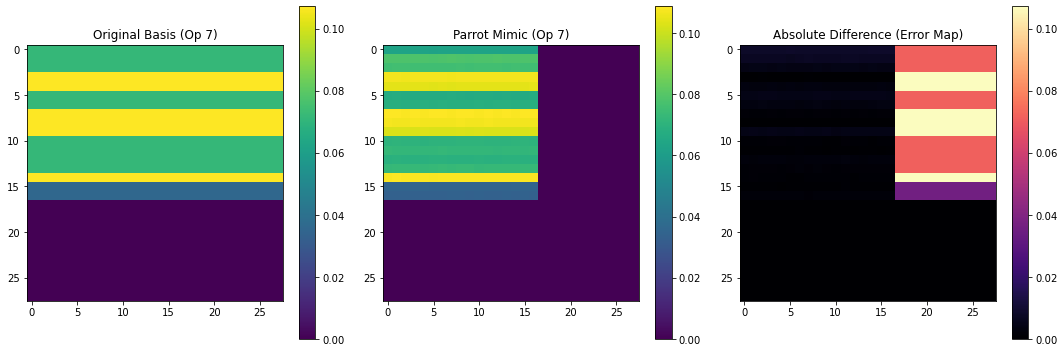

In [14]:
test_idx = 0
test_graph, _ = dataset[test_idx]
test_in = pad_adjacency_matrix(test_graph.adjacency_matrix())

# 1. Get real basis
real_basis = ops_2_to_2(test_in, N_MAX)
# 2. Get Parrot basis
parrot_basis = parrot_ops_2_to_2(test_in, N_MAX, winner['model'], y_min_per_ch, y_max_per_ch)

# Check Op 11 (Transpose) vs Transposed Op 10
# This proves if the "Logic" of the graph is preserved
real_sym_error = th.abs(real_basis[10] - th.transpose(real_basis[9], -2, -1)).mean()
parr_sym_error = th.abs(parrot_basis[10] - th.transpose(parrot_basis[9], -2, -1)).mean()

print(f"Original Symmetry Error: {real_sym_error:.8f}")
print(f"Parrot Symmetry Error:   {parr_sym_error:.8f}")

Original Symmetry Error: 0.00000000
Parrot Symmetry Error:   0.00031774


In [15]:
print(f"Original Output Sample: {out_orig}")

Original Output Sample: tensor([[15.8235, -3.0946]], grad_fn=<AddmmBackward0>)
